In [2]:
import numpy as np
import sympy as sym
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display

Something to note is that scipy sparse matrices was chosen to compute and the tridiagonal matrix. This was done as it only stores the non-zero entries, which saves computation. If it was a dense matrix instead (had more numerical entries), numpy instead would have been used. 

The time independent Schrodinger equation is given by 

$$ \hat{H}\psi(x) = E\psi(x) $$

$$ -\frac{\hbar^2}{2m} \psi(x)'' + \hat{V}(x)\psi(x) = E\psi(x) $$

Which for harmonic oscilator potential $ \hat{V}(x) = \frac{1}{2}m\omega^2x^2 $ becomes

$$ -\frac{\hbar^2}{2m} \psi(x)'' + \frac{1}{2}m\omega^2x^2\psi(x) = E\psi(x) $$

We can non-dimensionalise this to simplify, first by rescaling with $ \xi = \frac{x}{l} $ or $ x = \xi l \implies \frac{d^2}{dx^2} = \frac{1}{l^2} \frac{d^2}{d\xi^2} $

$$ \therefore -\frac{\hbar^2}{2ml^2} \psi(\xi)'' + \frac{1}{2}m\omega^2\xi^2l^2\psi(\xi) = E\psi(\xi) $$

If we let $ l^2 = \frac{\hbar}{m\omega} $, then

$$ \therefore -\frac{\hbar^2m\omega}{2m\hbar} \psi(\xi)'' + \frac{1}{2m\omega}m\omega^2\xi^2\hbar\psi(\xi) = E\psi(\xi) $$

$$ -\frac{\hbar\omega}{2} \psi(\xi)'' + \frac{1}{2}\hbar\omega\xi^2\psi(\xi) = E\psi(\xi) $$

Dividing by $ \hbar\omega $

$$ -\frac{1}{2} \psi(\xi)'' + \frac{1}{2}\xi^2\psi(\xi) = \frac{E}{\hbar\omega}\psi(\xi) $$

Let $ \epsilon = \frac{E}{\hbar\omega} $, then

$$ -\frac{1}{2} \psi(\xi)'' + \frac{1}{2}\xi^2\psi(\xi) = \epsilon\psi(\xi) $$

We can make this into a homogenous equation

$$ -\frac{1}{2} \psi(\xi)'' + (\frac{\xi^2}{2} - \epsilon)\psi(\xi) = 0 $$

We use finite difference (specifically central difference construction) to discretise our equation, where

$$ f'(x) = \frac{f(x+h) - f(x-h)}{2h} \implies u_i' = \frac{u_{i+1} - u_{i-1}}{2\Delta x} $$

$$ f''(x) = \frac{f(x+h) - 2f(x) + f(x-h)}{h^2} \implies u_i'' = \frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta x^2} $$

Hence we discretise our equation

$$ -\frac{1}{2}(\frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta x^2}) + (\frac{\xi_i^2}{2} - \epsilon)u_i = 0 $$

$$ u_{i+1}(\frac{-1}{2\Delta \xi^2} ) + u_{i}(\frac{1}{\Delta \xi^2} + \frac{\xi_i^2}{2} - \epsilon) + u_{i-1}(\frac{-1}{2\Delta \xi^2}) = 0$$

$$ \implies u_{i+1}(\frac{-1}{2\Delta \xi^2} ) + u_{i}(\frac{1}{\Delta \xi^2} + \frac{\xi_i^2}{2}) + u_{i-1}(\frac{-1}{2\Delta \xi^2}) = \epsilon u_i$$

We can now put this into matrix form for $ c = \frac{-1}{2\Delta \xi^2} $ and $ d_i = \frac{1}{\Delta \xi^2} + \frac{\xi_i^2}{2} $


$$ \tilde{H}\psi = \epsilon \psi $$


$$  \begin{bmatrix}
d_1 & c_1 & 0 & \cdots & \cdots & 0 \\
c_1 & d_2 & c_2 & \ddots & & \vdots \\
0 & c_2 & d_3 & c_3 & \ddots & \vdots \\
\vdots & \ddots & \ddots & \ddots & \ddots & 0 \\
\vdots & & \ddots & c_{N-2} & d_{N-1} & c_{N-1} \\
0 & \cdots & \cdots & 0 & c_{N-1} & d_N
\end{bmatrix} 

\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_N
\end{bmatrix}

= \epsilon 
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_N
\end{bmatrix} $$




We have divided the domain up into $N$ grid points, with N-1 intervals of spacing $ \Delta \xi = \frac{2\xi_{max}}{N-1} $ 

By construction of the tridiagonal matrix, we are enforcing $ \psi(\xi_{max}), \psi(-\xi_{max}) \to 0 $ since we require as $ |\xi| \to \infty, \psi(|\xi|) \to 0 $ from the requirement $ \psi(|x|) \to 0 $ as $|x| \to \infty $. This is since at each end of the grid, $ \psi_{-1} $ (left) or $ \psi_{N+1} $ (right) cannot exist. So this forces $ \psi(\xi_0) = \psi(-\xi_{max}) = 0 $, and similarly $ \psi(\xi_N) = \psi(\xi_{max}) = 0 $

In [73]:
N      = 10000 # number of grid points
xi_max = 10 # domain: [-xi_max, +xi_max]
xi     = np.linspace(-xi_max, xi_max, N)
dxi    = xi[1] - xi[0]
 
# diagonal:     d_i = 1/dxi^2  +  xi_i^2 / 2
# off-diagonal: c = -1 / (2*dxi^2)   (uniform, symmetric)
c = -1.0 / (2.0 * dxi**2)
d = 1.0 / dxi**2  +  0.5 * xi**2
 
H = (diags(d, 0) # main diagonal
   + diags(np.full(N-1, c), 1) # upper off-diagonal
   + diags(np.full(N-1, c), -1)) # lower off-diagonal

In [74]:
# converted back to a dense array for display
display(sym.Matrix(H.toarray()[:5, :5])) # shows top left 5x5 block of the tridiagonal matrix

Matrix([
[ 250000.002500192, -124975.001250096,               0.0,               0.0,               0.0],
[-124975.001250096,  249999.982500193, -124975.001250096,               0.0,               0.0],
[              0.0, -124975.001250096,  249999.962504194, -124975.001250096,               0.0],
[              0.0,               0.0, -124975.001250096,  249999.942512195, -124975.001250096],
[              0.0,               0.0,               0.0, -124975.001250096,  249999.922524198]])

In [79]:
evalues, eigenfunctions = eigsh(H, k=5, which='SA') # SM = the k smallest magnitude eigenvalues
# here our eigenvalues = epsilon

In [90]:
print(f"Eigenfunctions matrix size is: {eigenfunctions.shape[0]}, {eigenfunctions.shape[1]}")

Eigenfunctions matrix size is: 10000, 5


In [92]:
# normalising eigenfunctions (trapezoidal integral approximation)
# eigenfunctions is a N x 5 array currently - since only have 5 lowest energy eigenfunctions
for n in range(eigenfunctions.shape[1]): # 5 iterations

    norm = np.sqrt(np.trapezoid(eigenfunctions[:, n]**2, xi))
    eigenfunctions[:, n] /= norm

Since theoretically we know $ E = \hbar\omega(n + \frac{1}{2}) $, recall $ \epsilon = \frac{E}{\hbar\omega} \implies \epsilon = n + \frac{1}{2} , \: n \in \set{0, 1, 2, ...} $

In [77]:
# showing 5 lowest eigenvalues (epsilon)
display(evalues)

array([0.49999987, 1.49999937, 2.49999837, 3.49999687, 4.49999487])

Our potential for the harmonic oscilator was $ \hat{V}(x) = \frac{1}{2}m\omega^2 x^2 $, and we made substitutions for non-dimensionalisation $ x = \xi l $ and chose $ l^2 = \frac{\hbar}{m\omega} $. 

Hence $ x = \xi l = \xi \sqrt(\frac{\hbar}{m\omega}) $

$$ \therefore \tilde{V}(\xi) = \frac{1}{2}m\omega^2 \cdot \frac{\hbar}{m\omega} \xi^2 = \frac{\hbar \omega}{2} \xi^2 $$

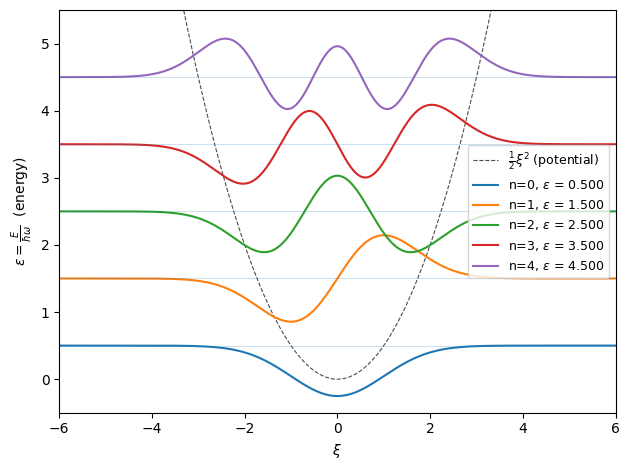

In [78]:
# plotting eigenfunctions at height of corresponding eigenvalue, with potential for reference

V = (1/2) * xi**2 # if we set omega = 1 (using hbar = 1 convention)

plt.plot(xi, V, 'k--', lw=0.8, alpha=0.7, label=r'$ \frac{1}{2} \xi^2 $ (potential)')

for n in range(5):

    plt.plot(xi, eigenfunctions[:, n] + evalues[n], label=fr'n={n}, $\epsilon$ = {evalues[n]:.3f}')
    plt.axhline(evalues[n], lw=0.4, alpha=0.4)

plt.xlim(-6, 6)
plt.ylim(-0.5, 5.5)
plt.xlabel(r'$\xi$')
plt.ylabel(r'$\epsilon = \frac{E}{\hbar\omega}$  (energy)')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()